# Model Selection With Optuna on new_dataset

This notebook compares **Random Forest**, **SVM**, and **XGBoost** on the flat `new_dataset` using:
- Existing image channels (all channels already stored in each image TIFF)
- Extra ratio-style features derived from selected spectral channels

Classes considered in this notebook: **0=Unknown, 1=Greenery, 2=Sand, 3=Water, 4=Cement**.

Optuna searches hyperparameters *and* model family, then reports the best model.

In [1]:
import importlib.util
import subprocess
import sys

def ensure_package(pkg_name):
    if importlib.util.find_spec(pkg_name) is None:
        print(f'Installing {pkg_name}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg_name])

ensure_package('optuna')
ensure_package('xgboost')
print('Package check complete.')

Package check complete.


In [2]:
from pathlib import Path
import random
import warnings

import numpy as np
import rasterio
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import jaccard_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier

import optuna

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

DATASET_DIR = Path(r'c:/satellite/project/new_dataset')
TARGET_CLASSES = [0, 1, 2, 3, 4]
CLASS_NAMES = {0: 'Unknown', 1: 'Greenery', 2: 'Sand', 3: 'Water', 4: 'Cement'}

# Channel order in new_dataset image TIFFs
# 0:B2, 1:B3, 2:B4, 3:B5, 4:B6, 5:B7, 6:B8, 7:B8A, 8:B11, 9:B12
CHANNEL_NAMES = ['B2','B3','B4','B5','B6','B7','B8','B8A','B11','B12']
EPS = 1e-6

image_paths = sorted(DATASET_DIR.glob('*_img.tif'))
mask_paths = sorted(DATASET_DIR.glob('*_msk.tif'))

def sample_id(p: Path) -> str:
    return p.name.replace('_img.tif', '').replace('_msk.tif', '')

img_lookup = {sample_id(p): p for p in image_paths}
msk_lookup = {sample_id(p): p for p in mask_paths}
paired_ids = sorted(set(img_lookup) & set(msk_lookup))
pairs = [(img_lookup[sid], msk_lookup[sid]) for sid in paired_ids]

print(f'Dataset: {DATASET_DIR}')
print(f'Paired samples: {len(pairs)}')
print(f'Unmatched images: {len(set(img_lookup) - set(msk_lookup))}')
print(f'Unmatched masks: {len(set(msk_lookup) - set(img_lookup))}')

Dataset: c:\satellite\project\new_dataset
Paired samples: 517
Unmatched images: 1
Unmatched masks: 0


c:\Users\user\.pyenv\pyenv-win\versions\3.12.2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def local_mean_3x3(feature_maps: np.ndarray) -> np.ndarray:
    """Compute 3x3 neighborhood means for a stack of feature maps (C,H,W)."""
    padded = np.pad(feature_maps, ((0, 0), (1, 1), (1, 1)), mode='reflect')
    windows = np.lib.stride_tricks.sliding_window_view(
        padded, window_shape=(3, 3), axis=(1, 2)
    )
    return windows.mean(axis=(-1, -2))

def build_features(image_cube: np.ndarray) -> np.ndarray:
    """
    image_cube: (C,H,W)
    returns:    (H*W, F) where F = selected bands + indices + ratios + local context
    Selected bands exclude B1, B9, and B10.
    """
    spectral_raw = image_cube[:10].astype(np.float32)

    # Preprocess reflectance-like bands from 16-bit range [0,10000] when needed.
    spectral_scale_probe = np.nanpercentile(spectral_raw, 99)
    if spectral_scale_probe > 2.0:
        spectral_norm = np.clip(spectral_raw / 10000.0, 0.0, 1.0)
    else:
        spectral_norm = np.clip(spectral_raw, 0.0, 1.0)

    b2, b3, b4, b5, b6, b7, b8, b8a, b11, b12 = spectral_norm

    # Physical indices
    ndvi = (b8 - b4) / (b8 + b4 + EPS)
    ndwi = (b3 - b8) / (b3 + b8 + EPS)
    ndbi = (b11 - b8) / (b11 + b8 + EPS)
    mndwi = (b3 - b11) / (b3 + b11 + EPS)
    physical_indices = np.stack([ndvi, ndwi, ndbi, mndwi], axis=0)

    # Ratio features
    ratio_nir_red = b8 / (b4 + EPS)
    ratio_red_green = b4 / (b3 + EPS)
    ratio_nir_swir1 = b8 / (b11 + EPS)
    ratio_swir1_swir2 = b11 / (b12 + EPS)
    ratio_blue_green = b2 / (b3 + EPS)
    derived = np.stack([
        ratio_nir_red,
        ratio_red_green,
        ratio_nir_swir1,
        ratio_swir1_swir2,
        ratio_blue_green,
    ], axis=0)


    spectral_flat = np.moveaxis(spectral_norm, 0, -1).reshape(-1, spectral_norm.shape[0])
    physical_flat = np.moveaxis(physical_indices, 0, -1).reshape(-1, physical_indices.shape[0])
    derived_flat = np.moveaxis(derived, 0, -1).reshape(-1, derived.shape[0])

    features = np.concatenate([spectral_flat, physical_flat], axis=1).astype(np.float32)
    return features

FEATURE_NAMES = [
    'B2',
    'B3',
    'B4',
    'B5',
    'B6',
    'B7',
    'B8',
    'B8A',
    'B11',
    'B12',
    'NDVI',
    'NDWI',
    'NDBI',
    'MNDWI',
]

print(f'Feature count: {len(FEATURE_NAMES)}')
print(FEATURE_NAMES)

Feature count: 14
['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12', 'NDVI', 'NDWI', 'NDBI', 'MNDWI']


In [4]:
def collect_stratified_pixels(
    paired_paths,
    target_per_class=50000,
    per_patch_cap=350,
    seed=RANDOM_STATE
):
    rng = np.random.default_rng(seed)

    X_chunks = []
    y_chunks = []
    collected = {c: 0 for c in TARGET_CLASSES}

    order = np.arange(len(paired_paths))
    rng.shuffle(order)

    for idx in order:
        img_path, msk_path = paired_paths[idx]

        with rasterio.open(img_path) as src:
            image_cube = src.read().astype(np.float32)

        with rasterio.open(msk_path) as src:
            mask = src.read(1).astype(np.int32)

        feats = build_features(image_cube)
        mask_flat = mask.reshape(-1)

        for cls in TARGET_CLASSES:
            remaining = target_per_class - collected[cls]
            if remaining <= 0:
                continue

            cls_idx = np.where(mask_flat == cls)[0]
            if cls_idx.size == 0:
                continue

            take = min(remaining, per_patch_cap, cls_idx.size)
            chosen = rng.choice(cls_idx, size=take, replace=False)
            X_chunks.append(feats[chosen])
            y_chunks.append(np.full(take, cls, dtype=np.int32))
            collected[cls] += int(take)

        if all(collected[c] >= target_per_class for c in TARGET_CLASSES):
            break

    X = np.vstack(X_chunks).astype(np.float32)
    y = np.concatenate(y_chunks).astype(np.int32)

    print('Collected per class:')
    for cls in TARGET_CLASSES:
        print(f'  {cls} ({CLASS_NAMES[cls]}): {collected[cls]:,}')
    if not all(collected[c] >= target_per_class for c in TARGET_CLASSES):
        print('Warning: at least one class did not reach target_per_class. The run will continue with available pixels.')
    print(f'Total sampled pixels: {len(y):,}')

    return X, y

X, y = collect_stratified_pixels(
    pairs,
    target_per_class=100000000,
    per_patch_cap=1000
)

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f'X_train: {X_train.shape} | X_val: {X_val.shape}')

Collected per class:
  0 (Unknown): 19,633
  1 (Greenery): 144,302
  2 (Sand): 265,526
  3 (Water): 156,951
  4 (Cement): 211,478
Total sampled pixels: 797,890
X_train: (638312, 14) | X_val: (159578, 14)


In [5]:
def make_model(trial):
    params = {
        'n_estimators': trial.suggest_int('rf_n_estimators', 150, 300),
        'max_depth': trial.suggest_int('rf_max_depth', 2, 20),
        'min_samples_split': trial.suggest_int('rf_min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('rf_min_samples_leaf', 1, 10),
        'max_features': 'sqrt',
        'bootstrap': True,
        'n_jobs': -1,
        'random_state': RANDOM_STATE
    }
    model = RandomForestClassifier(**params)
    return 'random_forest', model

def objective(trial):
    model_type, model = make_model(trial)
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    score = jaccard_score(
        y_val,
        preds,
        labels=TARGET_CLASSES,
        average='macro',
        zero_division=0
    )
    trial.set_user_attr('model_type', model_type)
    return score

In [6]:
N_TRIALS = 10

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print('Best Optuna trial:')
print(f'  Value (mIoU): {study.best_value:.4f}')
print(f'  Params: {study.best_params}')

[I 2026-04-20 19:45:35,623] A new study created in memory with name: no-name-aae3d3d4-abfc-4436-ae4e-4a770826f386
Best trial: 0. Best value: 0.781199:  10%|█         | 1/10 [00:46<07:02, 46.95s/it]

[I 2026-04-20 19:46:22,568] Trial 0 finished with value: 0.7811989355282435 and parameters: {'rf_n_estimators': 206, 'rf_max_depth': 20, 'rf_min_samples_split': 8, 'rf_min_samples_leaf': 6}. Best is trial 0 with value: 0.7811989355282435.


Best trial: 0. Best value: 0.781199:  20%|██        | 2/10 [01:00<03:36, 27.10s/it]

[I 2026-04-20 19:46:35,773] Trial 1 finished with value: 0.5813178826353255 and parameters: {'rf_n_estimators': 173, 'rf_max_depth': 4, 'rf_min_samples_split': 2, 'rf_min_samples_leaf': 9}. Best is trial 0 with value: 0.7811989355282435.


Best trial: 0. Best value: 0.781199:  30%|███       | 3/10 [01:48<04:18, 36.97s/it]

...

[I 2026-04-20 19:49:43,577] Trial 7 finished with value: 0.42427753171940996 and parameters: {'rf_n_estimators': 239, 'rf_max_depth': 2, 'rf_min_samples_split': 7, 'rf_min_samples_leaf': 2}. Best is trial 0 with value: 0.7811989355282435.


Best trial: 0. Best value: 0.781199:  90%|█████████ | 9/10 [04:42<00:29, 29.20s/it]

[I 2026-04-20 19:50:18,097] Trial 8 finished with value: 0.7689527132049705 and parameters: {'rf_n_estimators': 159, 'rf_max_depth': 20, 'rf_min_samples_split': 10, 'rf_min_samples_leaf': 9}. Best is trial 0 with value: 0.7811989355282435.


Best trial: 0. Best value: 0.781199: 100%|██████████| 10/10 [04:53<00:00, 29.39s/it]

[I 2026-04-20 19:50:29,525] Trial 9 finished with value: 0.5754595308483703 and parameters: {'rf_n_estimators': 195, 'rf_max_depth': 3, 'rf_min_samples_split': 8, 'rf_min_samples_leaf': 5}. Best is trial 0 with value: 0.7811989355282435.
Best Optuna trial:
  Value (mIoU): 0.7812
  Params: {'rf_n_estimators': 206, 'rf_max_depth': 20, 'rf_min_samples_split': 8, 'rf_min_samples_leaf': 6}


In [7]:
for trial in study.trials:
    print(f"Trial #{trial.number}")
    print(f"  Value (mIoU): {trial.value}")
    print(f"  Params: {trial.params}")
    print(f"  State: {trial.state}")
    print("-" * 40)

Trial #0
  Value (mIoU): 0.7811989355282435
  Params: {'rf_n_estimators': 206, 'rf_max_depth': 20, 'rf_min_samples_split': 8, 'rf_min_samples_leaf': 6}
  State: TrialState.COMPLETE
----------------------------------------
Trial #1
  Value (mIoU): 0.5813178826353255
  Params: {'rf_n_estimators': 173, 'rf_max_depth': 4, 'rf_min_samples_split': 2, 'rf_min_samples_leaf': 9}
  State: TrialState.COMPLETE
----------------------------------------
Trial #2
  Value (mIoU): 0.7298533214541041
  Params: {'rf_n_estimators': 240, 'rf_max_depth': 15, 'rf_min_samples_split': 2, 'rf_min_samples_leaf': 10}
  State: TrialState.COMPLETE
----------------------------------------
Trial #3
  Value (mIoU): 0.6211104697137557
  Params: {'rf_n_estimators': 275, 'rf_max_depth': 6, 'rf_min_samples_split': 3, 'rf_min_samples_leaf': 2}
  State: TrialState.COMPLETE
----------------------------------------
Trial #4
  Value (mIoU): 0.686286862192907
  Params: {'rf_n_estimators': 195, 'rf_max_depth': 11, 'rf_min_samples

In [ ]:
best_trial = study.best_trial
best_model_type = 'random_forest'

best_type, best_model = make_model(best_trial)
assert best_type == best_model_type

best_model.fit(X_train, y_train)

In [11]:

y_pred = best_model.predict(X_val)
val_miou = jaccard_score(
    y_val,
    y_pred,
    labels=TARGET_CLASSES,
    average='macro',
    zero_division=0
)

## test on the train to check for overfitting
y_train_pred = best_model.predict(X_train)
train_miou = jaccard_score(
    y_train,
    y_train_pred,
    labels=TARGET_CLASSES,
    average='macro',
    zero_division=0
)
## check for f1 score as well
train_report = classification_report(y_train, y_train_pred, labels=TARGET_CLASSES, target_names=[CLASS_NAMES[c] for c in TARGET_CLASSES])

print(f'Train mIoU: {train_miou:.4f}')
print('Train classification report:')
print(train_report)

print(f'Best model family: {best_model_type}')
print(f'Validation mIoU: {val_miou:.4f}')
print('Validation classification report:')
print(classification_report(y_val, y_pred, labels=TARGET_CLASSES, target_names=[CLASS_NAMES[c] for c in TARGET_CLASSES]))

Train mIoU: 0.8449
Train classification report:
              precision    recall  f1-score   support

     Unknown       0.94      0.77      0.85     15706
    Greenery       0.91      0.93      0.92    115442
        Sand       0.96      0.92      0.94    212421
       Water       0.99      0.98      0.99    125561
      Cement       0.85      0.91      0.88    169182

    accuracy                           0.93    638312
   macro avg       0.93      0.90      0.91    638312
weighted avg       0.93      0.93      0.93    638312

Best model family: random_forest
Validation mIoU: 0.7812
Validation classification report:
              precision    recall  f1-score   support

     Unknown       0.86      0.68      0.76      3927
    Greenery       0.86      0.88      0.87     28860
        Sand       0.94      0.90      0.92     53105
       Water       0.99      0.98      0.98     31390
      Cement       0.80      0.85      0.82     42296

    accuracy                           0.89   

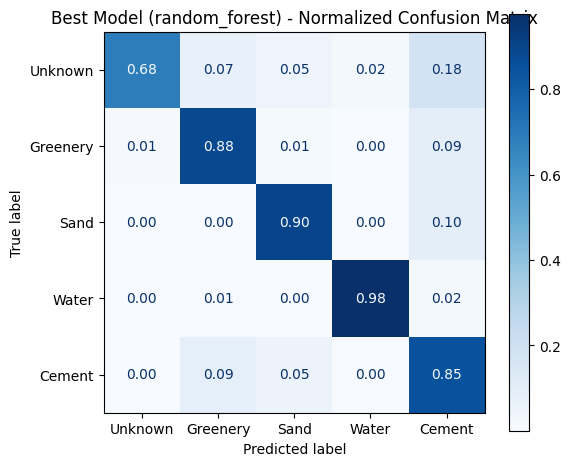

In [9]:
cm = confusion_matrix(y_val, y_pred, labels=TARGET_CLASSES, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[CLASS_NAMES[c] for c in TARGET_CLASSES])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', values_format='.2f', colorbar=True)
plt.title(f'Best Model ({best_model_type}) - Normalized Confusion Matrix')
plt.tight_layout()
plt.show()

In [12]:
import pickle

out_path = DATASET_DIR.parent / 'best_optuna_model.pkl'
payload = {
    'model': best_model,
    'model_type': best_model_type,
    'feature_names': FEATURE_NAMES,
    'class_names': CLASS_NAMES,
    'best_value_miou': study.best_value,
    'best_params': study.best_params
}

with open(out_path, 'wb') as f:
    pickle.dump(payload, f)

print(f'Saved: {out_path}')

Saved: c:\satellite\project\best_optuna_model.pkl
